### Programming for Biomedical Informatics
#### Week 10 - Simple SNF

Here we are going to simulate a set of three graphs representing patient similarity networks generated from different modalities and then fuse them using similarity network fusion.

This uses the SNFPy package:

https://github.com/rmarkello/snfpy
pip install snfpy

This implements the algorithm described in:

Wang, B., Mezlini, A. M., Demir, F., Fiume, M., Tu, Z., Brudno, M., Haibe-Kains, B., & Goldenberg, A. (2014)
Similarity network fusion for aggregating data types on a genomic scale. Nature Methods, 11(3), 333.

In [2]:
# SNFpy throws some warnings we can ignore
import warnings
warnings.filterwarnings('ignore')

In [7]:
from itertools import combinations
import numpy as np

# create a list of N patients
patientIDs = ['patient'+str(number) for number in list(range(1,21,1))]

# use itertools to get all pairs (where we don't get both 1-2 and 2-1) and no self-loops
pairs = combinations(patientIDs,2)

# edge number
N = len(list(pairs))

# from this build an edge_matrix
edge_matrix = np.zeros((N, 3))

# for each row (pair) generate 3 random numbers between 0 and 1 that sum to 1.0
for i in range(N):
    random_vals = np.random.random(3)
    edge_matrix[i] = random_vals / random_vals.sum()  # normalize to sum to 1.0

# randomly drop one of the numbers for each pair (this is to introduce missing data)
for i in range(N):
    # randomly choose one of the 3 columns (0, 1, or 2)
    col_to_zero = np.random.choice([0, 1, 2])
    edge_matrix[i, col_to_zero] = 0.0

# each column is a weighted edge list to build the three graphs to be fused 

In [11]:
edge_matrix

array([[0.        , 0.42569207, 0.48343766],
       [0.3168362 , 0.26832893, 0.        ],
       [0.1482055 , 0.59309675, 0.        ],
       [0.05999277, 0.0798007 , 0.        ],
       [0.37549242, 0.        , 0.44098578],
       [0.        , 0.23337012, 0.36335592],
       [0.44940315, 0.16774525, 0.        ],
       [0.        , 0.37763331, 0.28184599],
       [0.28899388, 0.29205708, 0.        ],
       [0.        , 0.36152206, 0.12628988],
       [0.        , 0.48049573, 0.15860861],
       [0.        , 0.34273692, 0.59172165],
       [0.        , 0.32783901, 0.29070203],
       [0.31636278, 0.4746463 , 0.        ],
       [0.44031732, 0.        , 0.31360732],
       [0.52565123, 0.        , 0.41923827],
       [0.25608827, 0.        , 0.4578668 ],
       [0.347127  , 0.        , 0.29602571],
       [0.13577381, 0.        , 0.41651975],
       [0.24307782, 0.        , 0.33582604],
       [0.        , 0.46266802, 0.43090834],
       [0.60383328, 0.        , 0.13849072],
       [0.

In [8]:
# build a dataframe for each graph with the nodes extracted from the list(pairs) object and the weights from each column of edge_matrix
import pandas as pd

# list to hold the edges dataframes
edge_dfs = []

# for each column build the edge dataframe
for col in range(3):
    # reset pairs generator
    pairs = combinations(patientIDs,2)
    edge_list = []
    for i, (node1, node2) in enumerate(pairs):
        weight = edge_matrix[i, col]
        edge_list.append((node1, node2, weight))
    edge_df = pd.DataFrame(edge_list, columns=['node1', 'node2', 'weight'])
    edge_dfs.append(edge_df)
    
# print the first few rows of each dataframe
for i, df in enumerate(edge_dfs):
    print(f"Edge DataFrame for Graph {i+1}:")
    print(df.head())
    print()

Edge DataFrame for Graph 1:
      node1     node2    weight
0  patient1  patient2  0.000000
1  patient1  patient3  0.316836
2  patient1  patient4  0.148206
3  patient1  patient5  0.059993
4  patient1  patient6  0.375492

Edge DataFrame for Graph 2:
      node1     node2    weight
0  patient1  patient2  0.425692
1  patient1  patient3  0.268329
2  patient1  patient4  0.593097
3  patient1  patient5  0.079801
4  patient1  patient6  0.000000

Edge DataFrame for Graph 3:
      node1     node2    weight
0  patient1  patient2  0.483438
1  patient1  patient3  0.000000
2  patient1  patient4  0.000000
3  patient1  patient5  0.000000
4  patient1  patient6  0.440986



In [12]:
# build a graph for each column
import networkx as nx

# create three separate graphs (one for each column)
graphs = []

for col in range(3):
    # read in the graph directly from the dataframe
    G = nx.from_pandas_edgelist(edge_dfs[col], 'node1', 'node2', edge_attr='weight')
    graphs.append(G)
    # remove edges with zero weight
    edges_to_remove = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] <= 0.3]
    G.remove_edges_from(edges_to_remove)
    
    
# print basic info about each graph
for i, G in enumerate(graphs):
    print(f"Graph {i+1}:")
    # print the number of nodes and edges
    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")
    

Graph 1:
Number of nodes: 20
Number of edges: 63
Graph 2:
Number of nodes: 20
Number of edges: 77
Graph 3:
Number of nodes: 20
Number of edges: 73


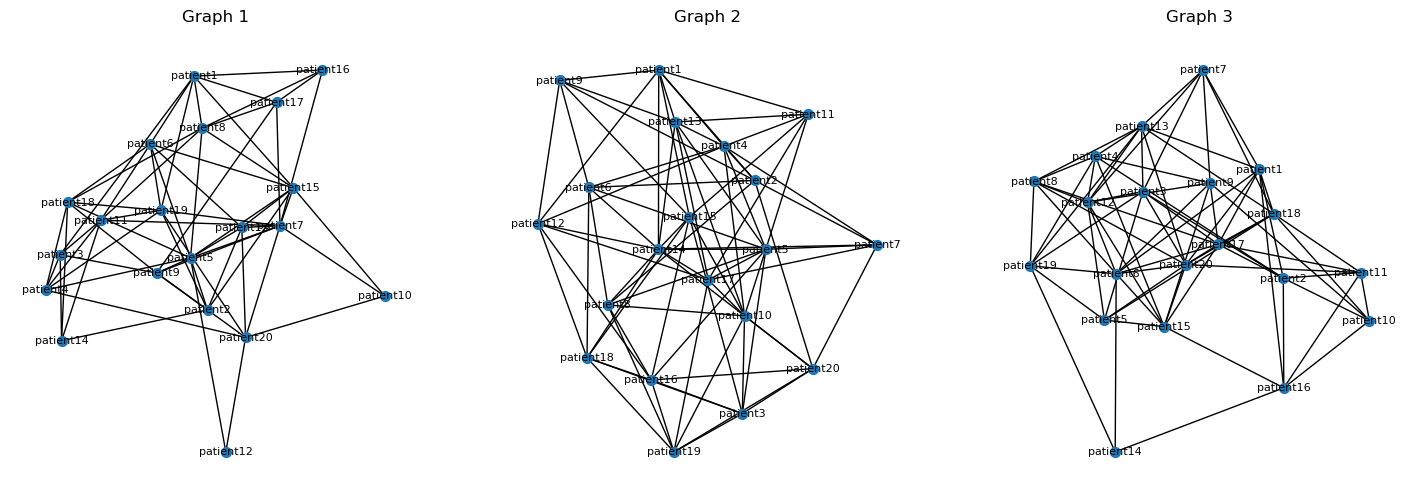

In [ ]:
# plot all three graphs side by side
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, G in enumerate(graphs):
    ax = axes[i]
    pos = nx.spring_layout(G, seed=42)  # positions for all nodes
    nx.draw(G, pos, ax=ax, with_labels=True, node_size=50, font_size=8)
    ax.set_title(f"Graph {i+1}")
plt.show()

# We imagine these are there different modalities e.g.:
# Left is gene expression correlation matrix, where the correlation is the similarity in the patient similarity gene expression
# DNA methalylation profile
# Protein expression data or text embedding of their clinical features
# We want to learn jointly across these three graphs to get the true relationship between paitents
# E.g. 11-14 not similar in Graph 1, but maybe in the other graphs they should be closer
# You can do this with more realistic distributions to figure these out as well




In [ ]:
# find the clustering coefficient of each graph
for i, G in enumerate(graphs):
    clustering_coeffs = nx.clustering(G)
    avg_clustering_coeff = sum(clustering_coeffs.values()) / len(clustering_coeffs)
    print(f"Average clustering coefficient for Graph {i+1}: {avg_clustering_coeff:.4f}")

    
# There are not evidence of clear clustering groups


Average clustering coefficient for Graph 1: 0.3271
Average clustering coefficient for Graph 2: 0.3977
Average clustering coefficient for Graph 3: 0.3969


In [15]:
#use SNFpy to fuse the graphs
import snf

# convert each graph to a pandas adjacency matrix
full_graphs = [] # List fo three graphs represented by their adjacency matrices


### SNF has two main phases:
# One of the networks as a reference and compare to the fusion of the other two
# Do that for all permutations to diffuse into other graphs - Affinity
# We then need to fuse by donig iterative local multiplication to amplify strong edges, and reduce weak edges
# There is then some tidy up to ensure there are no self loops

for graph in graphs:
    graph = nx.to_pandas_adjacency(graph)
    full_graphs.append(graph)

# perform SNF
affinity_networks = snf.make_affinity(full_graphs, metric='euclidean', K=20, mu=0.5)
# fuse the networks
fused_network = snf.snf(affinity_networks, K=20, t=20)

# remove self-loops
np.fill_diagonal(fused_network, 0)

Average clustering coefficient for Fused Graph: 1.0000


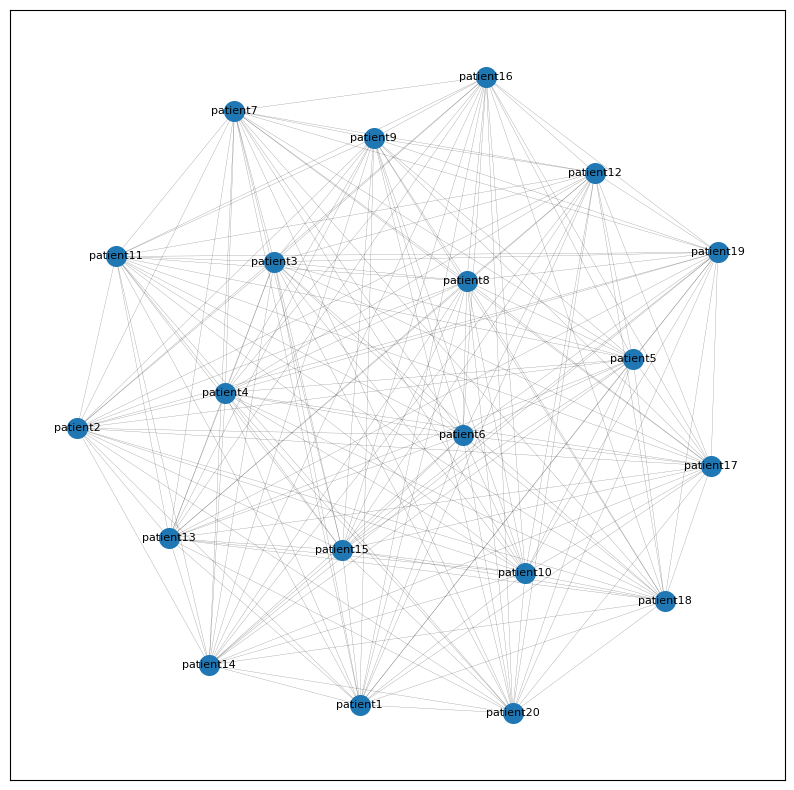

In [ ]:
# convert fused network to a graph
G = nx.Graph(fused_network)

# find the clustering coefficient of the fused graph
clustering_coeffs = nx.clustering(G)
avg_clustering_coeff = sum(clustering_coeffs.values()) / len(clustering_coeffs)
print(f"Average clustering coefficient for Fused Graph: {avg_clustering_coeff:.4f}")

plt.figure(figsize=(10, 10))

pos = nx.spring_layout(G, k=0.1, seed=50)
nx.draw_networkx_nodes(G, pos, node_size=200, cmap='tab20')
nx.draw_networkx_edges(G, pos, width=0.2, alpha=0.5)
# add node labels
labels = {i: f'patient{i+1}' for i in range(len(G.nodes()))}
nx.draw_networkx_labels(G, pos, labels, font_size=8)
plt.show()

## Let's look at the clustering coeeficient. All nodes are stiched together that gets us a coefficient of One
# Reminder for a directed graph, the global neighbourhood is the number of closed triplets / all triplet
# For the undirected, the local ceofficient of a node is the 2 times the number of edges in the neighbourhodd / number of nodes in the  neighbourhood(num nodes -1 )#
# For directed, its not two times, but same formula hold
